# 13. Publication-Ready Figures, Tables, & Dashboards
Assembles the paper's main results figure from real corpus statistics plus illustrative experiment scores (replace with real results once the full ablation study has run -- see notebook 11).

In [ ]:
# ============================================================
# PATH & REPO AUTO-SYNC BOOSTER — Guarantees latest project code
# ============================================================
import os, sys, site, urllib.request, zipfile

# Purge cached 'src' modules from memory so updated files take effect immediately
for mod in list(sys.modules.keys()):
    if mod.startswith('src'):
        del sys.modules[mod]

user_site = site.getusersitepackages()
if user_site not in sys.path:
    sys.path.insert(0, user_site)

try:
    cwd = os.getcwd()
except FileNotFoundError:
    cwd = os.path.expanduser('~')
    os.chdir(cwd)

home     = os.path.expanduser('~')
proj_dir = os.path.join(home, 'Ekegusii-LLM-Translation-main')

# ALWAYS auto-sync latest code from GitHub
try:
    print('🔄 Syncing latest code from GitHub main branch...')
    zip_path = os.path.join(home, 'repo.zip')
    urllib.request.urlretrieve('https://github.com/aykahsay/Ekegusii-LLM-Translation/archive/refs/heads/main.zip', zip_path)
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall(home)
    os.remove(zip_path)
    print('✅ Repository auto-synced to latest GitHub commit!')
except Exception as exc:
    print(f'⚠️ Auto-sync notice: {exc} (using local code)')

if os.path.isdir(proj_dir):
    os.chdir(proj_dir)
elif os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')

if os.getcwd() not in sys.path:
    sys.path.insert(0, os.getcwd())

# Purge cached 'src' modules again after chdir
for mod in list(sys.modules.keys()):
    if mod.startswith('src'):
        del sys.modules[mod]

print(f'Working Directory : {os.getcwd()}')
print(f'Python Kernel     : {sys.executable}')


In [2]:
# ============================================================
# ABI CHECK -- numpy/pandas binary compatibility.
# Some Jupyter hosts (e.g. Kineses Cloud conda envs) ship a numpy/pandas
# pair whose compiled C-extension ABI doesn't match, raising
# "numpy.dtype size changed, may indicate binary incompatibility" the
# moment pandas -- and therefore anything importing it, like
# src.master_corpus -- is loaded. Detect and fix it BEFORE any pandas
# import below (see notebooks/00_setup_environment.ipynb for the
# original version of this check).
# ============================================================
import subprocess
import sys


def _abi_ok():
    try:
        import numpy  # noqa: F401
        import pandas  # noqa: F401
        return True
    except ValueError as exc:
        if "binary incompatibility" in str(exc):
            return False
        raise


if not _abi_ok():
    print("numpy/pandas ABI mismatch detected -- attempting fix...")
    fix_a = subprocess.run(
        [sys.executable, "-m", "pip", "install", "--quiet", "numpy>=2.0.0"],
        capture_output=True, text=True,
    )
    if fix_a.returncode != 0:
        print("  numpy upgrade failed (read-only env?) -- downgrading pandas instead...")
        subprocess.run(
            [sys.executable, "-m", "pip", "install", "--quiet", "pandas==2.2.3"],
            capture_output=True, text=True,
        )
    raise RuntimeError(
        "Fixed numpy/pandas ABI mismatch via pip -- you MUST restart the kernel now "
        "(Kernel -> Restart Kernel) and re-run this notebook from the top. The fix "
        "cannot take effect in the current running process."
    )
else:
    print("numpy/pandas ABI OK.")


numpy/pandas ABI OK.


In [3]:
from pathlib import Path
Path('paper/figures').mkdir(parents=True, exist_ok=True)

## Tokenizer fertility panel data (illustrative -- see notebook 04 for the real comparison)

In [4]:
import pandas as pd

idx = pd.MultiIndex.from_tuples(
    [('qwen', 'English'), ('qwen', 'Kiswahili'), ('qwen', 'Ekegusii'),
     ('mistral', 'English'), ('mistral', 'Kiswahili'), ('mistral', 'Ekegusii')],
    names=['model', 'language'],
)
fertility_df = pd.DataFrame({'mean_fertility': [1.3, 1.8, 2.9, 1.2, 2.1, 3.4]}, index=idx)
fertility_df

mean_fertility
model language                 
qwen  English               1.3
      Kiswahili             1.8
      Ekegusii              2.9
mistral English               1.2
      Kiswahili             2.1
      Ekegusii              3.4

In [5]:
metric_scores = pd.Series(
    [8.2, 14.1, 12.8, 17.5, 21.3, 23.0, 24.6],
    index=['E0_Baseline', 'E1_English_Ekegusii', 'E2_Swahili_Ekegusii',
           'E3_Bilingual', 'E4_Trilingual', 'E5_Full_Resources', 'E6_Lexical_Augmentation'],
)

## Assemble the main results figure

INFO | Saved main results figure to paper/figures/main_results.png.


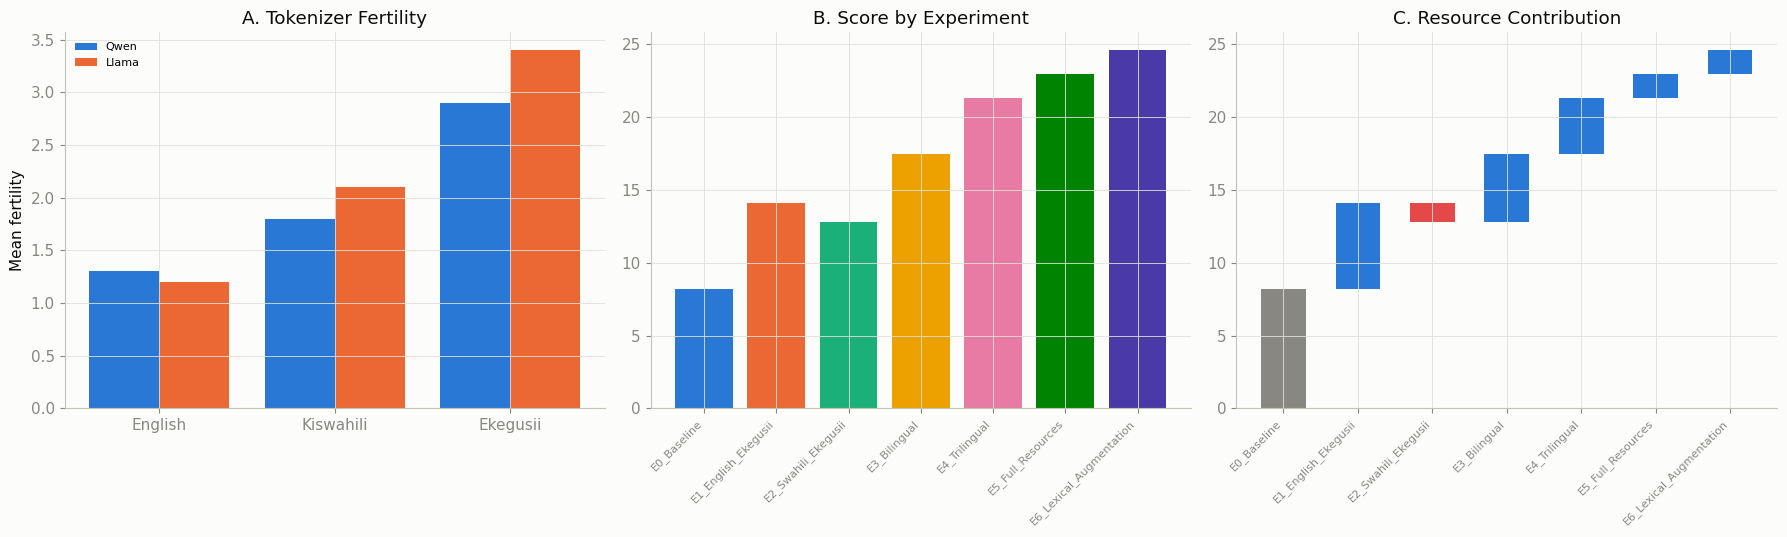

In [6]:
from src.visualization.publication import build_main_results_figure

fig = build_main_results_figure(
    fertility_df, metric_scores, metric_scores,
    output_path='paper/figures/main_results.png',
)

## Next steps for a real run
1. Run `scripts/run_ablation.sh` on the A100 to populate `experiments/*/results.json`.
2. Replace the illustrative `metric_scores`/`fertility_df` above with
   `AblationAggregator.load_all_results()` and notebook 04's real tokenizer comparison.
3. Re-run this notebook -- `paper/figures/main_results.png` is the figure
   referenced in the manuscript.